# Digit Recognizer

**Competição:** https://www.kaggle.com/competitions/digit-recognizer  
**Autora:** Juliana Burato  
**Algoritmo:** MLP (Multilayer Perceptron) com Data Augmentation  
**Acurácia no Kaggle:** 98.089%

---

## Descrição

Classificação de dígitos manuscritos (0–9) do dataset MNIST.
Cada imagem é representada por 784 valores de pixel (28×28), com intensidade de 0 a 255.

## Fluxo

```
train.csv / test.csv
    → EDA e visualização
    → Normalização + reshape (28×28×1) + one-hot encoding
    → Data Augmentation
    → MLP: Dense(256) → Dense(128) → Dense(64) → Softmax(10)
    → Early Stopping + ReduceLROnPlateau
    → submission.csv
```


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.19.0


## 2. Dados

| Arquivo | Linhas | Colunas |
|---|---|---|
| `train.csv` | 42.000 | 785 (label + 784 pixels) |
| `test.csv` | 28.000 | 784 (só pixels) |

**Upload no Colab:** ícone de pasta → upload → `train.csv` e `test.csv`


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv('/content/drive/MyDrive/kaggle_digit_recognir/train.csv')
test  = pd.read_csv('/content/drive/MyDrive/kaggle_digit_recognir/test.csv')

print(f'train: {train.shape}')
print(f'test:  {test.shape}')


train: (42000, 785)
test:  (28000, 784)


## 3. Análise Exploratória

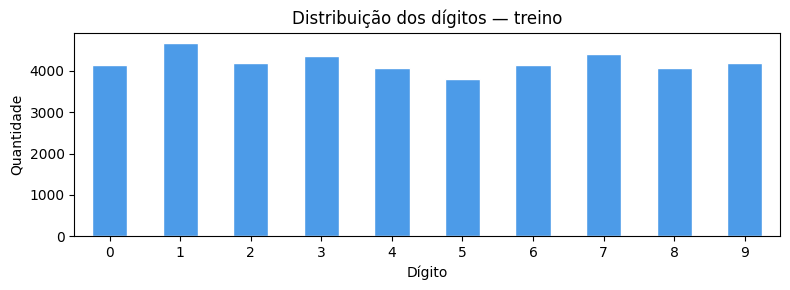

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188


In [4]:
# Dataset balanceado — ~4.200 exemplos por classe, sem necessidade de oversampling
plt.figure(figsize=(8, 3))
train['label'].value_counts().sort_index().plot(
    kind='bar', color='#4C9BE8', edgecolor='white'
)
plt.title('Distribuição dos dígitos — treino')
plt.xlabel('Dígito')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train['label'].value_counts().sort_index().to_string())


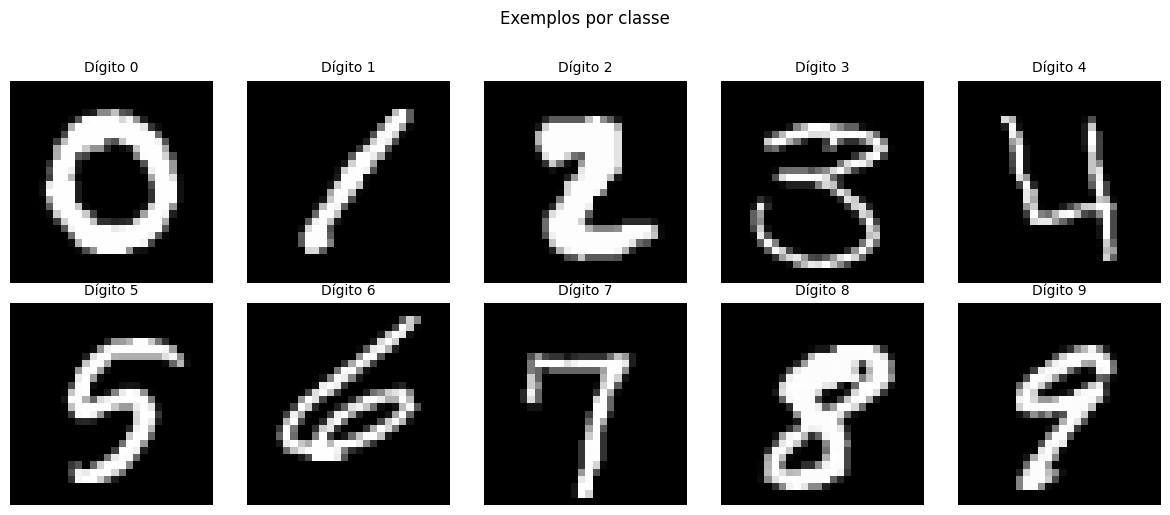

In [5]:
# Visualizar para identificar variações de escrita e possíveis confusões entre classes (ex: 4↔9, 3↔8)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digito, ax in zip(range(10), axes.flat):
    idx = train[train['label'] == digito].index[0]
    ax.imshow(train.iloc[idx, 1:].values.reshape(28, 28), cmap='gray')
    ax.set_title(f'Dígito {digito}', fontsize=10)
    ax.axis('off')
plt.suptitle('Exemplos por classe', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 4. Pré-processamento

- **Normalização:** pixels divididos por 255 → escala [0.0, 1.0]
- **Reshape:** `(n, 784)` → `(n, 28, 28, 1)` — mantém a estrutura espacial da imagem
- **One-hot encoding:** labels inteiros → vetores binários de dimensão 10


In [6]:
X            = train.drop('label', axis=1).values
y            = train['label'].values
X_test_final = test.values

# Normalização para [0, 1] — gradientes mais estáveis durante o backpropagation
X            = X.astype('float32').reshape(-1, 28, 28, 1) / 255.0
X_test_final = X_test_final.astype('float32').reshape(-1, 28, 28, 1) / 255.0

# Reshape para (n, 28, 28, 1) — preserva estrutura espacial vs. vetor achatado de 784
# One-hot: loss categorical_crossentropy requer labels nesse formato
y_cat = keras.utils.to_categorical(y, num_classes=10)

print(f'X:          {X.shape}')
print(f'y_cat:      {y_cat.shape}')
print(f'X_test:     {X_test_final.shape}')


X:          (42000, 28, 28, 1)
y_cat:      (42000, 10)
X_test:     (28000, 28, 28, 1)


In [7]:
# Validação sem augmentation — avalia o modelo em imagens reais, não artificiais
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print(f'Treino:    {X_tr.shape[0]:,}')
print(f'Validação: {X_val.shape[0]:,}')


Treino:    33,600
Validação: 8,400


## 5. Data Augmentation

Geração de variações sintéticas das imagens de treino para melhorar a generalização.
As transformações simulam variações naturais da escrita manual.

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `rotation_range` | 10° | Inclinação natural da escrita |
| `zoom_range` | 10% | Variação de tamanho entre escritores |
| `width_shift_range` | 10% | Deslocamento horizontal |
| `height_shift_range` | 10% | Deslocamento vertical |

> Transformações como espelhamento horizontal não são aplicadas —
> alterariam a identidade do dígito (ex: 6 ↔ 9).


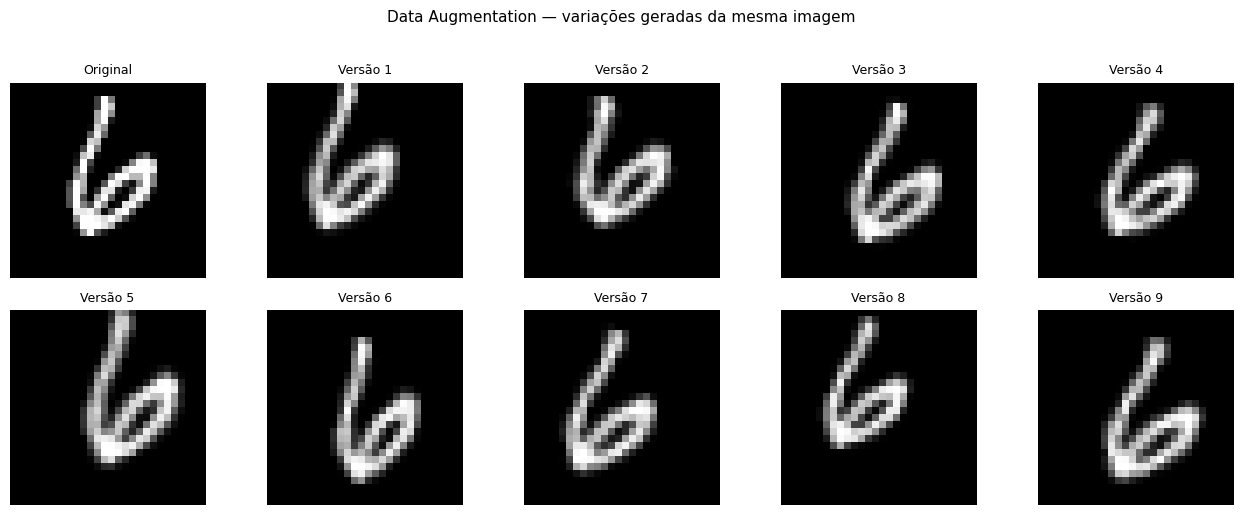

In [8]:
# Transformações conservadoras — espelhamento e rotações >15° alterariam a identidade do dígito
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
)
datagen.fit(X_tr)

# Visualizar o efeito do augmentation
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
axes[0][0].imshow(X_tr[0].reshape(28, 28), cmap='gray')
axes[0][0].set_title('Original', fontsize=9)
axes[0][0].axis('off')

gen = datagen.flow(X_tr[0:1], batch_size=1)
posicoes = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]
for i, (l, c) in enumerate(posicoes):
    axes[l][c].imshow(next(gen)[0].reshape(28, 28), cmap='gray')
    axes[l][c].set_title(f'Versão {i+1}', fontsize=9)
    axes[l][c].axis('off')

plt.suptitle('Data Augmentation — variações geradas da mesma imagem', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 6. Arquitetura — MLP

```
Input (28×28×1)
    → Flatten (784)
    → Dense(256) + BatchNorm + ReLU + Dropout(0.3)
    → Dense(128) + BatchNorm + ReLU + Dropout(0.3)
    → Dense(64)  + BatchNorm + ReLU + Dropout(0.2)
    → Dense(10)  + Softmax
```

| Componente | Função |
|---|---|
| BatchNormalization | Estabiliza e acelera o treino normalizando as ativações |
| Dropout | Regularização — desativa neurônios aleatoriamente para evitar overfitting |
| Softmax | Converte logits em distribuição de probabilidade (soma = 1) |


In [9]:
# Dropout decrescente (0.3 → 0.3 → 0.2) — camadas mais profundas precisam de menos regularização
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax'),  # softmax → distribuição de probabilidade sobre 10 classes
])

model.compile(
    optimizer='adam',                 # adam adapta o learning rate por parâmetro
    loss='categorical_crossentropy',  # perda padrão para classificação multiclasse com one-hot
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

## 7. Treinamento

**Callbacks:**
- `EarlyStopping`: interrompe o treino se `val_accuracy` não melhorar por 10 épocas; restaura os melhores pesos
- `ReduceLROnPlateau`: reduz o learning rate por fator 0.5 após 5 épocas sem melhora


In [10]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True  # reverte para os melhores pesos ao parar
)

# ReduceLROnPlateau evita ficar preso em mínimos locais reduzindo o passo quando estagna
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    verbose=1
)

# datagen.flow gera batches augmentados em tempo real — validação usa imagens originais
historico = model.fit(
    datagen.flow(X_tr, y_tr, batch_size=64),
    epochs=50,
    steps_per_epoch=len(X_tr) // 64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6762 - loss: 0.9866 - val_accuracy: 0.9236 - val_loss: 0.2549 - learning_rate: 0.0010
Epoch 2/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.8298 - loss: 0.5320 - val_accuracy: 0.9464 - val_loss: 0.1799 - learning_rate: 0.0010
Epoch 3/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8644 - loss: 0.4310 - val_accuracy: 0.9524 - val_loss: 0.1488 - learning_rate: 0.0010
Epoch 4/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.8797 - loss: 0.3789 - val_accuracy: 0.9624 - val_loss: 0.1232 - learning_rate: 0.0010
Epoch 5/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8897 - loss: 0.3486 - val_accuracy: 0.9629 - val_loss: 0.1191 - learning_rate: 0.0010
Epoch 6/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8994 - loss: 0.3211 - val_accuracy: 0.9674 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 7/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9070 - l

## 8. Avaliação

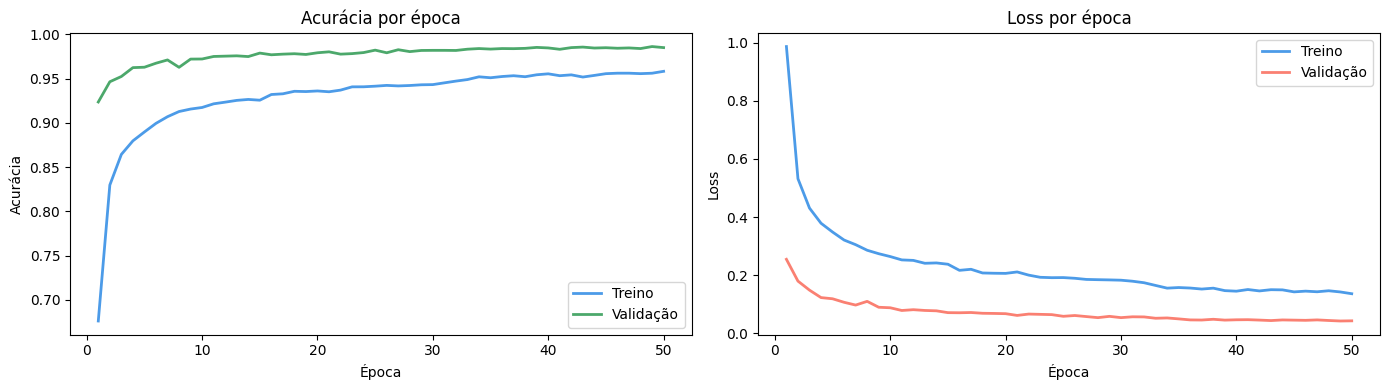

Melhor acurácia (validação): 0.9862


In [11]:
# Gap pequeno entre treino e validação indica boa generalização — augmentation contribui para isso
acc, val_acc = historico.history['accuracy'], historico.history['val_accuracy']
loss, val_loss = historico.history['loss'], historico.history['val_loss']
epocas = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epocas, acc,     label='Treino',    color='#4C9BE8', lw=2)
axes[0].plot(epocas, val_acc, label='Validação', color='#4CA86B', lw=2)
axes[0].set_title('Acurácia por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

axes[1].plot(epocas, loss,     label='Treino',    color='#4C9BE8', lw=2)
axes[1].plot(epocas, val_loss, label='Validação', color='salmon',  lw=2)
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Melhor acurácia (validação): {max(val_acc):.4f}')


In [12]:
# argmax sobre as probabilidades retorna o índice da classe com maior confiança
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
y_true = np.argmax(y_val, axis=1)

print(f'Acurácia na validação: {(y_pred == y_true).mean():.4f}')
print()
print(classification_report(y_true, y_pred,
                              target_names=[str(i) for i in range(10)]))


Acurácia na validação: 0.9862

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       816
           1       0.99      1.00      1.00       909
           2       0.98      0.99      0.99       846
           3       0.99      0.98      0.98       937
           4       0.99      0.98      0.98       839
           5       0.98      0.99      0.98       702
           6       0.98      0.99      0.99       785
           7       0.98      0.99      0.98       893
           8       0.99      0.97      0.98       835
           9       0.98      0.98      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



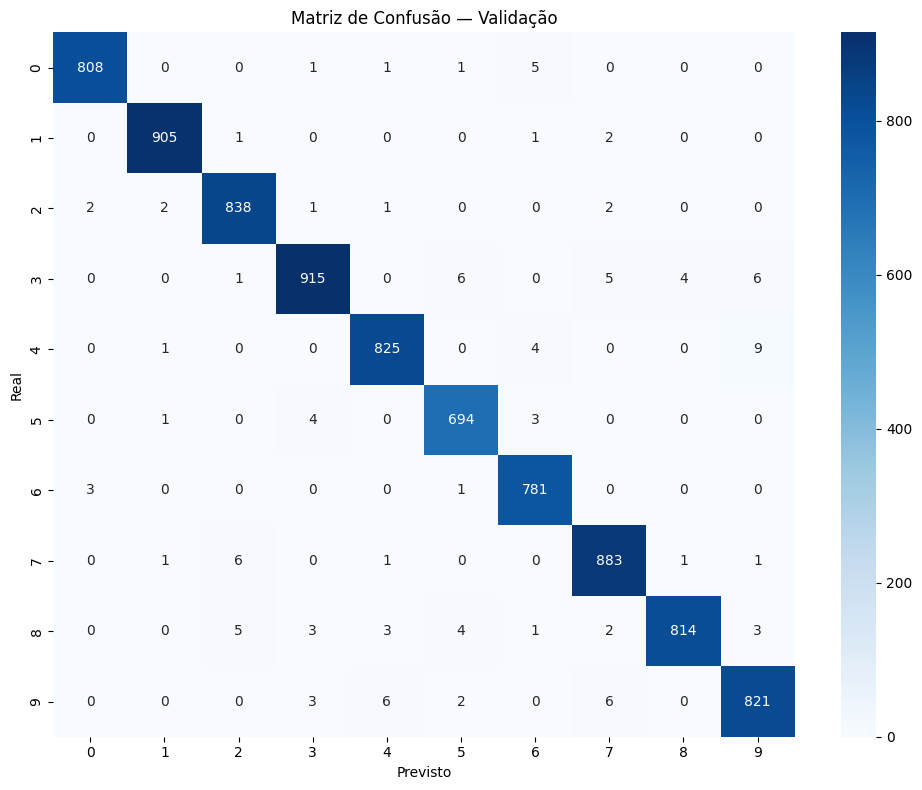

In [13]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusão — Validação')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


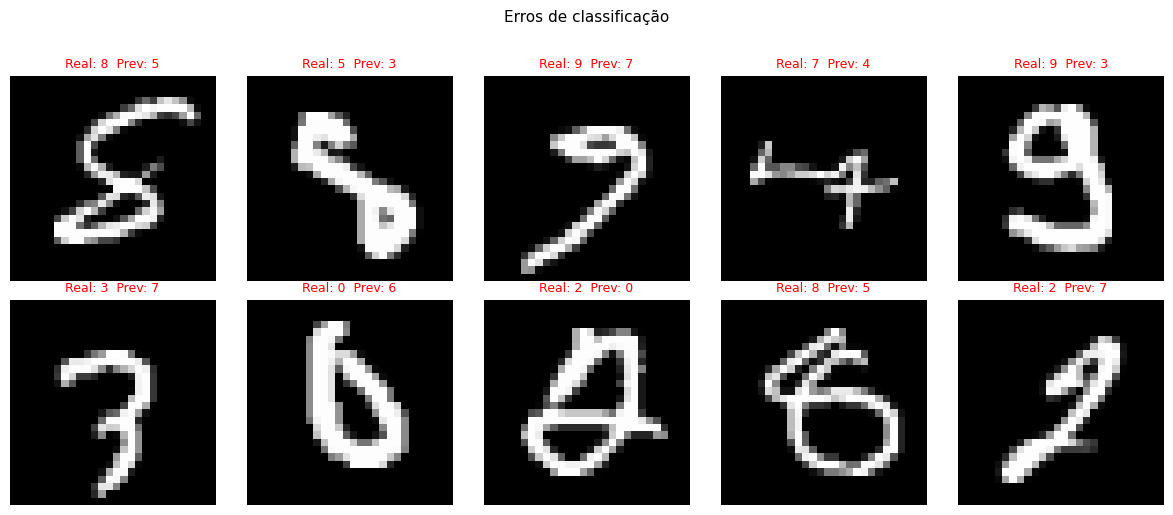

In [14]:
# Erros tendem a ser ambíguos visualmente — confirma que o modelo falha onde humanos também errariam
erros_idx = np.where(y_pred != y_true)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(erros_idx):
        idx = erros_idx[i]
        ax.imshow(X_val[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Real: {y_true[idx]}  Prev: {y_pred[idx]}',
                     fontsize=9, color='red')
        ax.axis('off')
plt.suptitle('Erros de classificação', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 9. Submissão

In [15]:
# Retreinar com todos os 42.000 exemplos pelo número de épocas que convergiu no experimento
n_epocas = len(historico.history['accuracy'])

model_final = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax'),
])

model_final.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_final.fit(
    datagen.flow(X, y_cat, batch_size=64),
    epochs=n_epocas,
    steps_per_epoch=len(X) // 64,
    verbose=0
)

print(f'Modelo retreinado com {len(X):,} imagens.')


Modelo retreinado com 42,000 imagens.


In [16]:
# argmax retorna o índice da classe com maior probabilidade — equivale ao dígito previsto
pred_label = np.argmax(model_final.predict(X_test_final, verbose=0), axis=1)

submission = pd.DataFrame({
    'ImageId': range(1, len(pred_label) + 1),
    'Label':   pred_label
})
submission.to_csv('submission.csv', index=False)

print(f'submission.csv — {len(submission):,} previsões')
submission.head(10)


submission.csv — 28,000 previsões


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
5,6,7
6,7,0
7,8,3
8,9,0
9,10,3
